# **Redes Neurais** (_Neural Networks_, NN)

## Perceptron

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## Problema linearmente separável

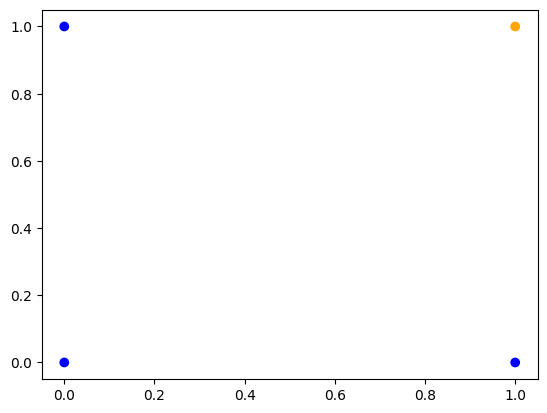

In [3]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
  ])
Y = np.array([1, 1, 1, 0])

plt.scatter(X[:, 0], X[:, 1], color=["blue" if v else "orange" for v in Y])
plt.show()

## **Função de Ativação**: Função Degau (_step function_)

Define-se a função de ativação degrau como:
$
f(x)=\begin{cases} 1 & \text{se } x \ge 0 \\ 0 & \text{se } x < 0 \end{cases}
$

In [4]:
def step(val: float) -> int:
  return 0 if val < 0 else 1

## Perceptron

In [5]:
class Perceptron:
  def __init__(self, *, input_size: int, learning_rate: float):
    self.bias = 1
    self.weights = np.zeros(input_size if input_size > 1 else 1)
    self.learning_rate = learning_rate

  def predict(self, inputs: np.ndarray) -> int:
    summation = np.dot(inputs, self.weights) + self.bias
    return step(summation)

  def train(self, x: np.ndarray, y: np.ndarray, *, epochs: int = 50):
    for epoch in range(epochs):
      for inputs, label in zip(x, y):
        prediction = self.predict(inputs)
        self.weights += self.learning_rate * (label - prediction) * inputs
        self.bias += self.learning_rate * (label - prediction) * 1

      if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch #{epoch + 1}\n=============")
        print(f"Bias = {self.bias}")
        print(f"W = {self.weights}")
        print("\n")



In [6]:
lr = 10 ** (-2) # 0.01
P = Perceptron(input_size=X.shape[1], learning_rate=lr)
P.train(X, Y, epochs=100)

Epoch #1
Bias = 0.99
W = [-0.01 -0.01]


Epoch #10
Bias = 0.8999999999999999
W = [-0.1 -0.1]


Epoch #20
Bias = 0.7999999999999998
W = [-0.2 -0.2]


Epoch #30
Bias = 0.6999999999999997
W = [-0.3 -0.3]


Epoch #40
Bias = 0.6599999999999997
W = [-0.34 -0.34]


Epoch #50
Bias = 0.6599999999999997
W = [-0.34 -0.34]


Epoch #60
Bias = 0.6599999999999997
W = [-0.34 -0.34]


Epoch #70
Bias = 0.6599999999999997
W = [-0.34 -0.34]


Epoch #80
Bias = 0.6599999999999997
W = [-0.34 -0.34]


Epoch #90
Bias = 0.6599999999999997
W = [-0.34 -0.34]


Epoch #100
Bias = 0.6599999999999997
W = [-0.34 -0.34]




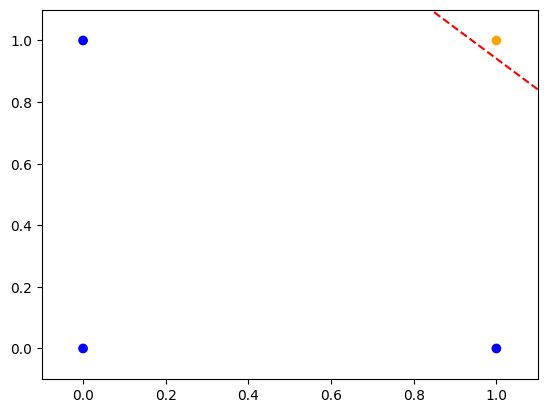

In [7]:
predictions = [P.predict(x_val) for x_val in X]
plt.scatter(X[:, 0], X[:, 1], color=["blue" if v else "orange" for v in predictions])

w1 = P.weights[0]
w2 = P.weights[1]

x_line = np.linspace(-0.5, 1.5, 100)
y_line = (-w1 * x_line - P.bias) / w2

plt.plot(x_line, y_line, color="red", linestyle="--")

plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def f(x):
    return x * np.sin(x)

def df(x):
    return np.sin(x) + x * np.cos(x)

x_range = np.linspace(-20, 20, 1000)
y_range = f(x_range)

def gradient_descent(start_x, learning_rate, epochs):
    x = start_x
    history = [x]
    for _ in range(epochs):
        grad = df(x)
        x = x - learning_rate * grad
        history.append(x)
    return history

#-------------------------------------------------------------------------------

lr = 0.2
n_epochs = 150

start_points = [-15.0, -8.0, -2.0, 2.0, 8.0, 15.0]
all_paths = [gradient_descent(sp, lr, n_epochs) for sp in start_points]

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(-20, 20)
ax.set_ylim(-20, 20)
ax.plot(x_range, y_range, "b-", alpha=0.3, label="f(x) = x * sin(x)")

lines = []
points = []
colors = ["red", "green", "yellow", "purple", "orange", "brown"]

for i, color in enumerate(colors):
    ln, = ax.plot([], [], "o-", color=color, markersize=4, alpha=0.6, label=f"Início: {start_points[i]}")
    pt, = ax.plot([], [], "o", color=color, markersize=8)
    lines.append(ln)
    points.append(pt)

def init():
    for ln, pt in zip(lines, points):
        ln.set_data([], [])
        pt.set_data([], [])
    return lines + points

def animate(i):
    for idx, path in enumerate(all_paths):
        current_path = path[:i+1]
        lines[idx].set_data(current_path, [f(p) for p in current_path])
        points[idx].set_data([path[i]], [f(path[i])])
    return lines + points

ani = FuncAnimation(fig, animate, frames=n_epochs, init_func=init, blit=True, interval=50)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=3)
plt.grid(True, linestyle="--", alpha=0.7)
plt.title("Descida do Gradiente com Múltiplos Pontos Iniciais")

plt.close()
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.